In [5]:
%matplotlib inline
from pathlib import Path
import gc
import os
import sys
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection, PathCollection
import torch
from graph_utils import draw_graph, pyg_to_networkx

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT/'src'/'lss').exists():
    ROOT = ROOT.parent
if str(ROOT/'src') not in sys.path:
    sys.path.insert(0, str(ROOT/'src'))
from lss.data import load_dataset
from lss.plotting import NETWORK_EDGE_COLOR, NETWORK_NODE_COLOR, apply_editorial_style
apply_editorial_style()

OUTPUT = ROOT/'notebooks'/'results'/'00_misc_paper_plots'
OUTPUT.mkdir(parents=True, exist_ok=True)
DATASETS = {
    'Reid': ('reid', ROOT/'data'/'reid_200_frames.pt'),
    'de Pablo': ('depablo', ROOT/'data'/'depablo-near-zero-temp.pt'),
    'Noisy LJ': ('lj_noisy', ROOT/'data'/'lj-noisy-eps0.01-sigma1.0-cutoff1.122_500sims_200frames.pt'),
}
assert all(path.exists() for _, path in DATASETS.values())


Reid


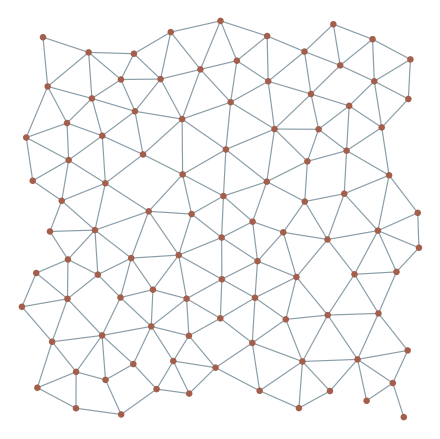

de Pablo


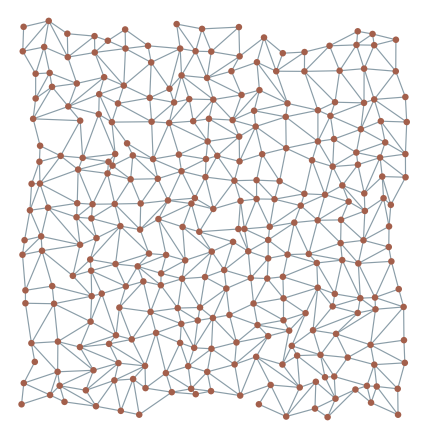

Noisy LJ


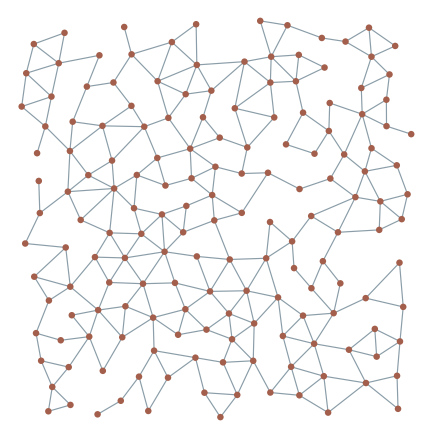

In [6]:
NODE_COLOR = NETWORK_NODE_COLOR
EDGE_COLOR = NETWORK_EDGE_COLOR
for display_name, (dataset_name, dataset_path) in DATASETS.items():
    print(display_name)
    trajectories = load_dataset(dataset_path, edge_multiplicity=1, edge_vector_dim=8)
    graph = trajectories[10][0].cpu()
    network = pyg_to_networkx(graph, collapse_undirected=True, pos_slice=(0, 2))
    if dataset_name == 'reid':
        zero_stiffness_edges = [
            (u, v) for u, v, attributes in network.edges(data=True)
            if abs(float(attributes.get('stiffness', 0.0))) <= 1e-12
        ]
        network.remove_edges_from(zero_stiffness_edges)

    positions = np.asarray([network.nodes[node]['pos'] for node in network.nodes], dtype=float)
    span = np.ptp(positions, axis=0)
    aspect = float(span[0] / max(span[1], 1e-8))
    height = 4.2
    fig, ax = plt.subplots(figsize=(height * aspect, height))
    draw_graph(
        network, periodic_edges=False, node_color=NODE_COLOR, node_size=22,
        show_angles=False, show_pos=False, show_labels=False, ax=ax, show=False,
    )
    for artist in ax.collections:
        if isinstance(artist, LineCollection):
            artist.set_color(EDGE_COLOR); artist.set_linewidth(0.85); artist.set_alpha(0.82)
        elif isinstance(artist, PathCollection):
            artist.set_facecolor(NODE_COLOR); artist.set_edgecolor('none')
    ax.set_axis_off()
    ax.grid(False)
    padding = 0.03 * np.maximum(span, 1e-8)
    ax.set_xlim(positions[:, 0].min() - padding[0], positions[:, 0].max() + padding[0])
    ax.set_ylim(positions[:, 1].min() - padding[1], positions[:, 1].max() + padding[1])
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    fig.savefig(OUTPUT/f'{dataset_name}_network.png', dpi=400, bbox_inches='tight', pad_inches=0)
    fig.savefig(OUTPUT/f'{dataset_name}_network.pdf', bbox_inches='tight', pad_inches=0)
    plt.show()

    del trajectories, graph, network
    gc.collect()
